In [29]:
import os
print(os.getcwd())

c:\Users\Trevor\Desktop\ev-charging-project\notebooks


In [30]:
import pandas as pd

df = pd.read_csv("../data/ev_charging_patterns.csv")    

In [31]:
df.head()  

,User ID,Vehicle Model,Battery Capacity (kWh),Charging Station ID,Charging Station Location,Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),Charging Cost (USD),Time of Day,Day of Week,State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),Charger Type,User Type
0,User_1,BMW i3,108.463007,Station_391,Houston,2024-01-01 00:00:00,2024-01-01 00:39:00,60.712346,0.591363,36.389181,13.087717,Evening,Tuesday,29.371576,86.119962,293.602111,27.947953,2.0,DC Fast Charger,Commuter
1,User_2,Hyundai Kona,100.000000,Station_428,San Francisco,2024-01-01 01:00:00,2024-01-01 03:01:00,12.339275,3.133652,30.677735,21.128448,Morning,Monday,10.115778,84.664344,112.112804,14.311026,3.0,Level 1,Casual Driver
2,User_3,Chevy Bolt,75.000000,Station_181,San Francisco,2024-01-01 02:00:00,2024-01-01 04:48:00,19.128876,2.452653,27.513593,35.667270,Morning,Thursday,6.854604,69.917615,71.799253,21.002002,2.0,Level 2,Commuter
3,User_4,Hyundai Kona,50.000000,Station_327,Houston,2024-01-01 03:00:00,2024-01-01 06:42:00,79.457824,1.266431,32.882870,13.036239,Evening,Saturday,83.120003,99.624328,199.577785,38.316313,1.0,Level 1,Long-Distance Traveler
4,User_5,Hyundai Kona,50.000000,Station_108,Los Angeles,2024-01-01 04:00:00,2024-01-01 05:46:00,19.629104,2.019765,10.215712,10.161471,Morning,Saturday,54.258950,63.743786,203.661847,-7.834199,1.0,Level 1,Long-Distance Traveler


In [32]:
def filter_risk(row):
    return 1 if row["State of Charge (Start %)"] < 20 else 0

def filter_weather(row):
    if row["Temperature (°C)"] < 7 or row["Temperature (°C)"] > 42:
        return 1
    return 0  

def filter_charging_habit(row):
    if 80 <= row["State of Charge (End %)"] <= 90:
        return 1
    return 0

def filter_car_age(row):
    return 1 if row["Vehicle Age (years)"] > 5 else 0

In [ ]:
df["Starting Battery Risk"] = df.apply(filter_risk, axis=1)
df["Weather Risk"] = df.apply(filter_weather, axis=1)
df["Charging Habit Risk"] = df.apply(filter_charging_habit, axis=1)
df["Car Age Risk"] = df.apply(filter_car_age, axis=1)
df.head()

,User ID,Vehicle Model,Battery Capacity (kWh),Charging Station ID,Charging Station Location,Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),...,State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),Charger Type,User Type,Starting Battery Risk,Weather Risk,Charging Habit Risk,Car Age Risk
0,User_1,BMW i3,108.463007,Station_391,Houston,2024-01-01 00:00:00,2024-01-01 00:39:00,60.712346,0.591363,36.389181,...,86.119962,293.602111,27.947953,2.0,DC Fast Charger,Commuter,0,0,1,0
1,User_2,Hyundai Kona,100.000000,Station_428,San Francisco,2024-01-01 01:00:00,2024-01-01 03:01:00,12.339275,3.133652,30.677735,...,84.664344,112.112804,14.311026,3.0,Level 1,Casual Driver,1,0,1,0
2,User_3,Chevy Bolt,75.000000,Station_181,San Francisco,2024-01-01 02:00:00,2024-01-01 04:48:00,19.128876,2.452653,27.513593,...,69.917615,71.799253,21.002002,2.0,Level 2,Commuter,1,0,0,0
3,User_4,Hyundai Kona,50.000000,Station_327,Houston,2024-01-01 03:00:00,2024-01-01 06:42:00,79.457824,1.266431,32.882870,...,99.624328,199.577785,38.316313,1.0,Level 1,Long-Distance Traveler,0,0,0,0
4,User_5,Hyundai Kona,50.000000,Station_108,Los Angeles,2024-01-01 04:00:00,2024-01-01 05:46:00,19.629104,2.019765,10.215712,...,63.743786,203.661847,-7.834199,1.0,Level 1,Long-Distance Traveler,0,1,0,0


In [34]:
import numpy as np

mean_distance = np.mean(df["Distance Driven (since last charge) (km)"])
std_distance = np.std(df["Distance Driven (since last charge) (km)"])

def filter_distance_risk(row):
    actual_dist = row["Distance Driven (since last charge) (km)"]
    
    # If they drove more than 2 standard deviations past average -> High Risk (2 points)
    if actual_dist > (mean_distance + (2 * std_distance)):
        return 2
    # If they drove more than 1 standard deviation past average -> Little Risk (1 point)
    elif actual_dist > (mean_distance + std_distance):
        return 1
    else:
        return 0
    
df["Distance Risk"] = df.apply(filter_distance_risk, axis=1)

In [ ]:
#sum up all the risk factors to get a total risk score
df["Total Risk Score"] = df["Starting Battery Risk"] + df["Weather Risk"] + df["Charging Habit Risk"] + df["Car Age Risk"] + df["Distance Risk"]

df.head()

,User ID,Vehicle Model,Battery Capacity (kWh),Charging Station ID,Charging Station Location,Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),...,Temperature (°C),Vehicle Age (years),Charger Type,User Type,Starting Battery Risk,Weather Risk,Charging Habit Risk,Car Age Risk,Distance Risk,Total Risk Score
0,User_1,BMW i3,108.463007,Station_391,Houston,2024-01-01 00:00:00,2024-01-01 00:39:00,60.712346,0.591363,36.389181,...,27.947953,2.0,DC Fast Charger,Commuter,0,0,1,0,1,2
1,User_2,Hyundai Kona,100.000000,Station_428,San Francisco,2024-01-01 01:00:00,2024-01-01 03:01:00,12.339275,3.133652,30.677735,...,14.311026,3.0,Level 1,Casual Driver,1,0,1,0,0,2
2,User_3,Chevy Bolt,75.000000,Station_181,San Francisco,2024-01-01 02:00:00,2024-01-01 04:48:00,19.128876,2.452653,27.513593,...,21.002002,2.0,Level 2,Commuter,1,0,0,0,0,1
3,User_4,Hyundai Kona,50.000000,Station_327,Houston,2024-01-01 03:00:00,2024-01-01 06:42:00,79.457824,1.266431,32.882870,...,38.316313,1.0,Level 1,Long-Distance Traveler,0,0,0,0,0,0
4,User_5,Hyundai Kona,50.000000,Station_108,Los Angeles,2024-01-01 04:00:00,2024-01-01 05:46:00,19.629104,2.019765,10.215712,...,-7.834199,1.0,Level 1,Long-Distance Traveler,0,1,0,0,0,1


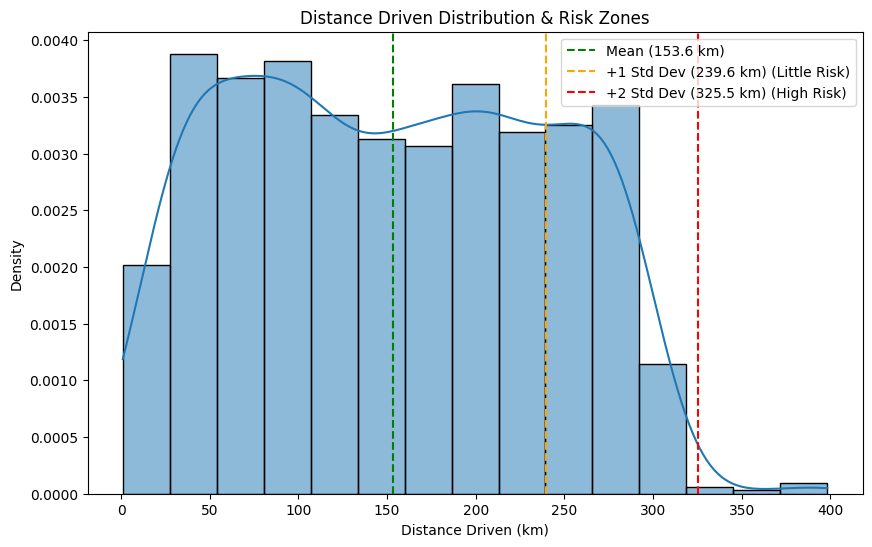

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(df["Distance Driven (since last charge) (km)"], kde=True, stat="density")

plt.axvline(mean_distance, color="green", linestyle="--", label=f"Mean ({mean_distance:.1f} km)")
plt.axvline(mean_distance + std_distance, color="orange", linestyle="--", label=f"+1 Std Dev ({mean_distance + std_distance:.1f} km) (Little Risk)")
plt.axvline(mean_distance + (2 * std_distance), color="red", linestyle="--", label=f"+2 Std Dev ({mean_distance + (2 * std_distance):.1f} km) (High Risk)")

plt.title("Distance Driven Distribution & Risk Zones")
plt.xlabel("Distance Driven (km)")
plt.ylabel("Density")
plt.legend()
plt.show()

#std deviation distribution of distance driven to determine risk thresholds

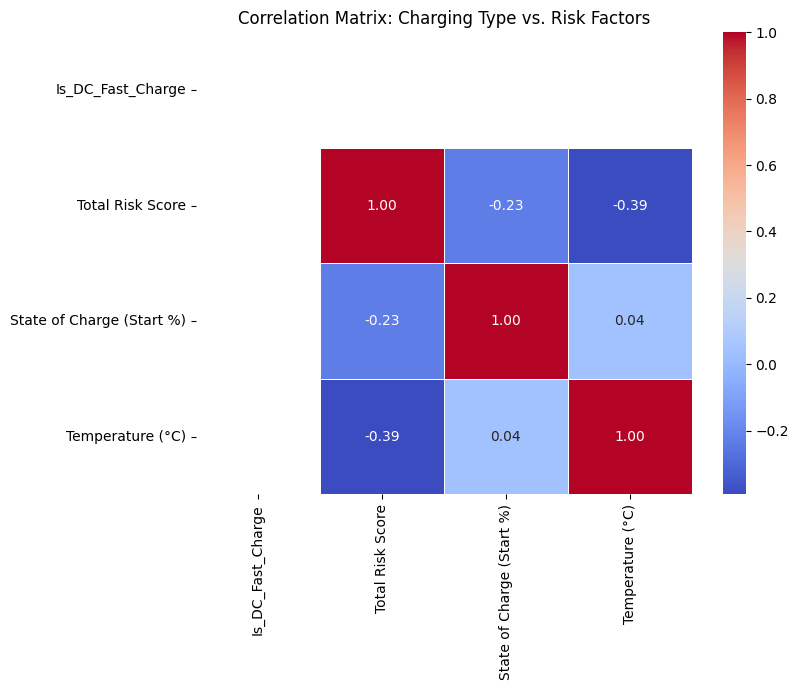

In [ ]:
df["Is_DC_Fast_Charge"] = (df["Charger Type"] == "DC Fast Charge").astype(int)
df["Is_DC_Fast_Charge"] = df["Is_DC_Fast_Charge"].astype(int)
correlation_features = ["Is_DC_Fast_Charge", "Total Risk Score", "State of Charge (Start %)", "Temperature (°C)"]
corr_matrix = df[correlation_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Charging Type vs. Risk Factors")
plt.show()

#correlation between DC Fast Charging and Risk

C:\Users\Trevor\AppData\Local\Temp\ipykernel_7044\3581171514.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="User Type", y="Total Risk Score", palette="Set2")


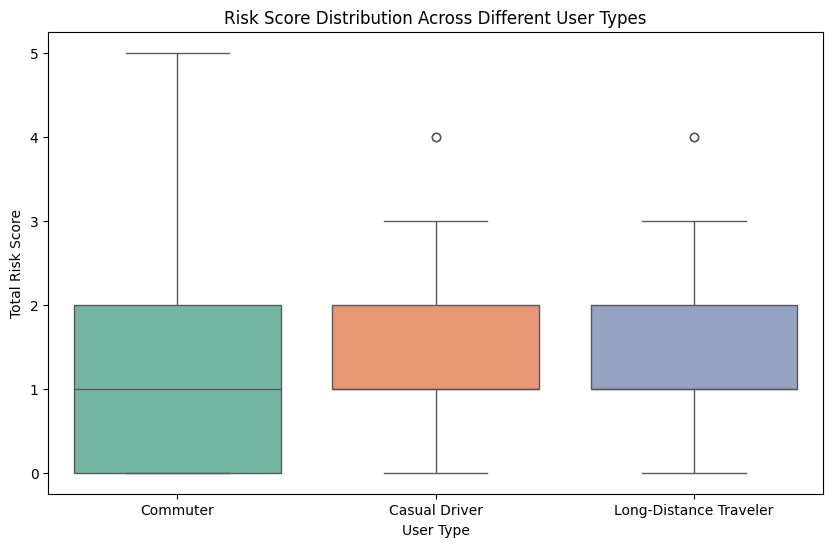

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x="User Type", y="Total Risk Score", palette="Set2")

plt.title("Risk Score Distribution Across Different User Types")
plt.xlabel("User Type")
plt.ylabel("Total Risk Score")
plt.show()

#distribution of risk scores across user types

In [69]:

df["Is_DC_Fast_Charge"] = (df["Charger Type"] == "DC Fast Charger").astype(int)

fast_charge_corr = df["Is_DC_Fast_Charge"].corr(df["Total Risk Score"])

print("==================================================")
print("       EV PIPELINE CORRELATION ANALYSIS           ")
print("==================================================")
print(f"Correlation (DC Fast Charger vs. Total Risk): {fast_charge_corr:.4f}")
print("--------------------------------------------------")

if pd.isna(fast_charge_corr):
    print("Interpretation: NaN.")
elif fast_charge_corr > 0.1:
    print("Interpretation: Positive correlation. Drivers using DC Fast Chargers")
    print("tend to have higher overall risk profiles.")
elif fast_charge_corr < -0.1:
    print("Interpretation: Negative correlation. Drivers using DC Fast Chargers")
    print("tend to have lower risk profiles.")
else:
    print("Interpretation: Near-zero correlation. There is no meaningful linear")
    print("relationship between DC Fast Charging usage and the trip risk score.")
print("==================================================")

       EV PIPELINE CORRELATION ANALYSIS           
Correlation (DC Fast Charger vs. Total Risk): 0.0337
--------------------------------------------------
Interpretation: Near-zero correlation. There is no meaningful linear
relationship between DC Fast Charging usage and the trip risk score.


In [ ]:
user_analysis = df.groupby("User Type")[["State of Charge (Start %)", "Total Risk Score"]].mean()
print(user_analysis)

                        State of Charge (Start %)  Total Risk Score
User Type                                                          
Casual Driver                           47.452858          1.142506
Commuter                                49.799512          1.159664
Long-Distance Traveler                  49.962779          1.212815
